In [29]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline
import seaborn as sns
import plotly.io as pio
pio.renderers.default = 'notebook'


import warnings
warnings.filterwarnings("ignore")

sns.set_style('darkgrid')
sns.set_palette('muted')

In [30]:
url = "https://raw.githubusercontent.com/MSalah-Data/Python-Projects/refs/heads/main/Anime%20Analysis_Python%20Project/anime.csv"
df = pd.read_csv(url)
pd.set_option("display.max_columns", None )
df.head(5)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [31]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


(12294, 7)

In [32]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [33]:
df[df['rating'] <0]

,anime_id,name,genre,type,episodes,rating,members


In [34]:
df['anime_id'].nunique()

12294

In [35]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12017 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12017 non-null  int64  
 1   name      12017 non-null  object 
 2   genre     12017 non-null  object 
 3   type      12017 non-null  object 
 4   episodes  12017 non-null  object 
 5   rating    12017 non-null  float64
 6   members   12017 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 751.1+ KB


In [37]:
df.sample(10)

,anime_id,name,genre,type,episodes,rating,members
10800,12791,Yankee Reppuu-tai,"Adventure, Drama, Shounen",OVA,6,5.88,110
7304,33803,Sengoku Choujuu Giga,"Demons, Historical, Supernatural",TV,26,5.56,3248
9083,30777,Kaijuu Sakaba Kanpai!,"Comedy, Supernatural",TV,13,4.90,262
7694,765,Chou Henshin Cosprayers Specials,"Adventure, Comedy, Magic, Sci-Fi",Special,3,5.13,1480
9485,10709,Manga Nihon Keizai Nyuumon,Drama,TV,25,6.67,86
1964,2634,Doraemon: Doraemon Comes Back,"Comedy, Fantasy, Kids, Sci-Fi, Shounen",Special,1,7.39,723
3516,14751,Bishoujo Senshi Sailor Moon Crystal,"Demons, Magic, Romance, Shoujo",ONA,26,6.96,69702
3733,2938,Idol Densetsu Eriko,Music,TV,51,6.90,1776
8652,23265,Genroku Koi Moyou: Sankichi to Osayo,"Adventure, Romance",Movie,1,4.93,108
1664,27969,Hana to Alice: Satsujin Jiken,"Drama, Mystery, Slice of Life",Movie,1,7.47,9766


In [38]:
df['name'] = df['name'].str.replace('&quot;', '"', regex=False)
df['name'] = df['name'].str.replace('&amp;', '&', regex=False)

In [39]:
df.sample(5)

,anime_id,name,genre,type,episodes,rating,members
2168,1303,The Animatrix,"Action, Drama, Sci-Fi",OVA,9,7.34,42831
1433,5538,Tegamibachi: Hikari to Ao no Gensou Yawa,"Adventure, Fantasy, Shounen, Slice of Life, Su...",Special,1,7.55,10903
155,20651,Natsume Yuujinchou: Itsuka Yuki no Hi ni,"Drama, Fantasy, Shoujo, Slice of Life, Superna...",OVA,1,8.40,28302
4474,2284,Transformers: Car Robots,"Adventure, Comedy, Mecha, Sci-Fi, Shounen",TV,39,6.72,2524
1658,20509,Fate/kaleid liner Prisma☆Illya 2wei!,"Action, Comedy, Fantasy, Magic",TV,10,7.47,56859


In [46]:
top10 = df.sort_values(by='members', ascending=False).head(10)
top10[['name', 'members']]

,name,members
40,Death Note,1013917
86,Shingeki no Kyojin,896229
804,Sword Art Online,893100
1,Fullmetal Alchemist: Brotherhood,793665
159,Angel Beats!,717796
19,Code Geass: Hangyaku no Lelouch,715151
841,Naruto,683297
3,Steins;Gate,673572
445,Mirai Nikki (TV),657190
131,Toradora!,633817


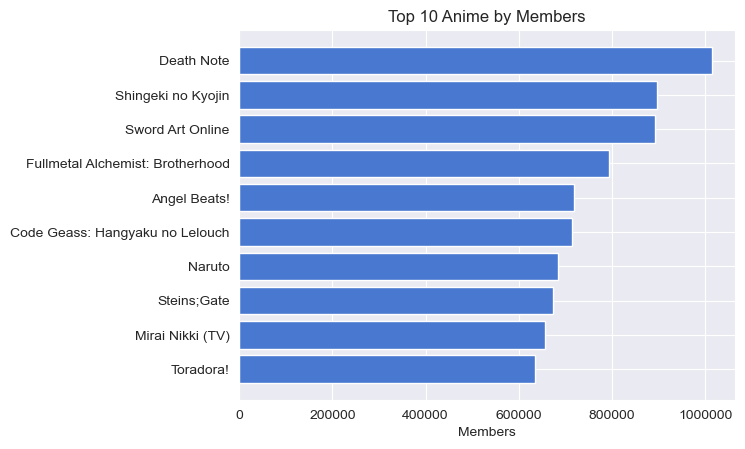

In [43]:
plt.barh(top10['name'], top10['members'])
plt.gca().invert_yaxis()
plt.xlabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

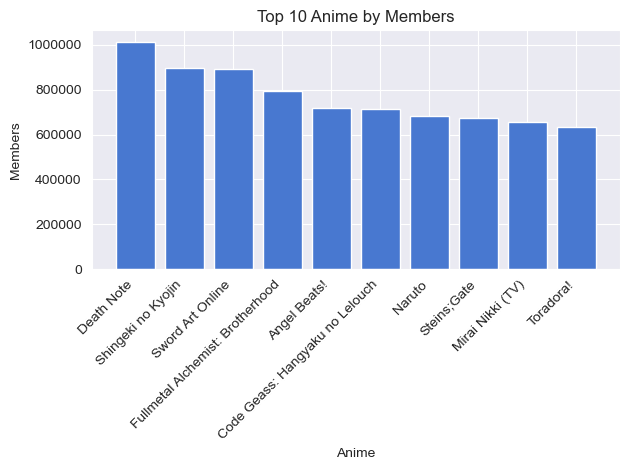

In [47]:
plt.figure()
plt.bar(top10['name'], top10['members'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Anime')
plt.ylabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [48]:
type_counts = df['type'].value_counts()

type_counts

type
TV         3668
OVA        3284
Movie      2259
Special    1670
ONA         648
Music       488
Name: count, dtype: int64

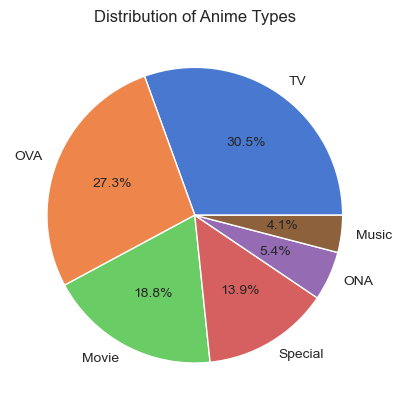

In [49]:
plt.figure()
type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distribution of Anime Types')
plt.show()

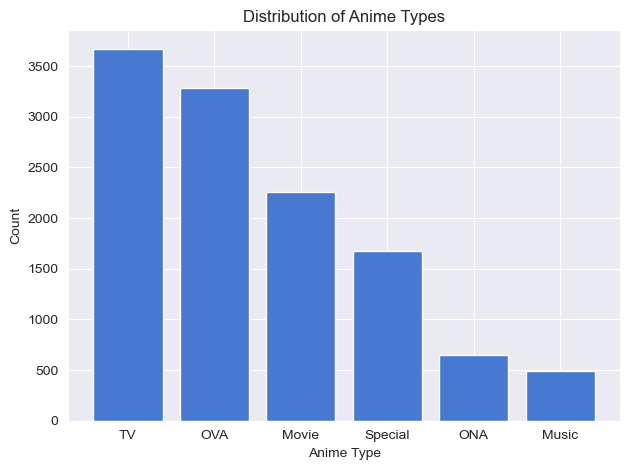

In [50]:
plt.figure()
plt.bar(type_counts.index, type_counts.values)

plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types')

plt.tight_layout()
plt.show()

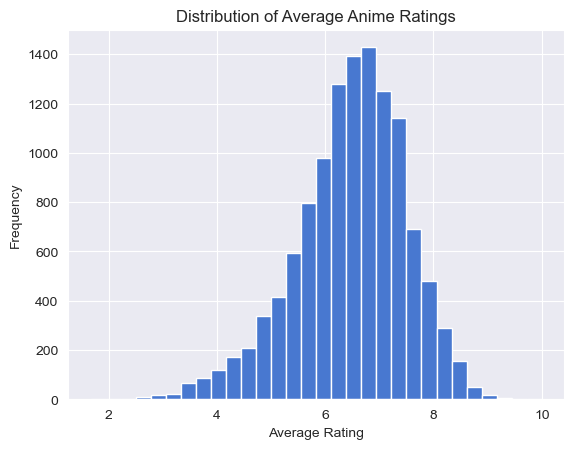

In [51]:
plt.figure()
plt.hist(df['rating'], bins=30)

plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Average Anime Ratings')

plt.show()

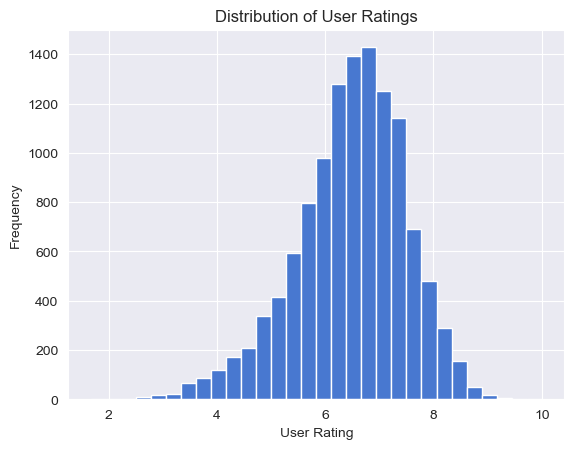

In [52]:
plt.figure()
plt.hist(df['rating'], bins=30)

plt.xlabel('User Rating')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')

plt.show()